# Module 2: Appreciating, Interpreting and Visualizing Data

**Project: Understanding Customer Segments for Targeted Marketing**

Introduction: The Power of Customer Segmentation
---



Welcome to your Module 2 project!

In today's competitive landscape, understanding your customers is paramount for any business. Generic marketing strategies often fall flat, but by truly appreciating the diverse needs and behaviors within your customer base, businesses can create more effective, personalized experiences. This process is known as **customer segmentation**,

Customer segmentation involves dividing a broad customer base into subgroups of consumers who have common needs, interests, and priorities. By segmenting customers, companies can:

* **Tailor Marketing Messages:** Design specific campaigns that resonate with each group.
* **Optimize Product Development:** Create products and services that meet the unique demands of different segments.
* **Improve Customer Service:** Provide support that addresses common issues for particular groups.
* **Identify High-Value Customers:** Focus resources on segments that drive the most revenue.
* **Predict Churn:** Identify customers at risk of leaving and intervene proactively.

In this project, your task is to analyze a dataset of customer activity, use dimensionality reduction techniques to visualize customer behavior, and ultimately identify distinct customer segments. This will demonstrate how data visualization can provide actionable insights for business strategy, even without deep domain expertise at the outset.

We will first focus on a synthetic dataset containing various metrics related to customer purchasing habits and engagement. Your goal will be to:
* Process and prepare the raw customer data.
* Use **Principal Component Analysis (PCA)** to understand the main drivers of customer variation.
* Employ **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to uncover hidden clusters of similar customers.
* (Optional Challenge) Explore **Uniform Manifold Approximation and Projection (UMAP)** for an alternative perspective.
* Interpret these visualizations to describe potential customer segments and suggest business implications.

Let's begin by setting up our environment and loading our customer data!


# 1. Data Acquisition and Initial Exploration

For this tutorial, we will first work with a synthetic dataset named ecommerce_customer_data.csv. This file contains anonymized data representing various aspects of customer engagement and purchasing behavior over a period.

First, let's ensure we have our necessary libraries installed and then load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [14]:
try:
    data = pd.read_csv("customer_data.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("customer_data.csv not found. Creating a synthetic dataset...")
    # Setting random seed for reproducibility
np.random.seed(57)

# Number of synthetic customers
num_customers = 650

# Creating synthetic e-commerce customer dataset
data = pd.DataFrame({
    'CustomerID': np.arange(1001, 1001 + num_customers),
    'Age': np.random.normal(36, 11, num_customers).astype(int).clip(18, 68),
    'Gender': np.random.choice(
        ['Male', 'Female'],
        num_customers,
        p=[0.48, 0.52]
    ),

    'Average_Order_Value': np.random.normal(
        85, 35, num_customers
    ).round(2).clip(min=8),

    'Number_of_Purchases': np.random.randint(
        1, 45, num_customers
    ),

    'Days_Since_Last_Purchase': np.random.randint(
        1, 240, num_customers
    ),

    'Product_Category_Preference': np.random.choice(
        ['Electronics', 'Fashion', 'Books', 'Home Decor', 'Beauty', 'Sports'],
        num_customers
    ),

    'Customer_Lifetime_Value': np.random.normal(
        450, 180, num_customers
    ).round(2).clip(min=20)
})

# Younger customers prefer electronics and fashion
data.loc[
    data['Age'] < 26,
    'Product_Category_Preference'
] = np.random.choice(
    ['Electronics', 'Fashion'],
    sum(data['Age'] < 26)
)

# Younger customers generally spend slightly less
data.loc[
    data['Age'] < 26,
    'Average_Order_Value'
] = np.random.normal(
    55, 18, sum(data['Age'] < 26)
).round(2).clip(min=8)

# Book buyers purchase more frequently
data.loc[
    data['Product_Category_Preference'] == 'Books',
    'Number_of_Purchases'
] = np.random.randint(
    12, 55,
    sum(data['Product_Category_Preference'] == 'Books')
)

# High-value book customers
data.loc[
    data['Product_Category_Preference'] == 'Books',
    'Customer_Lifetime_Value'
] = np.random.normal(
    650, 220,
    sum(data['Product_Category_Preference'] == 'Books')
).round(2).clip(min=25)

# Frequent shoppers tend to spend more
data.loc[
    data['Number_of_Purchases'] > 30,
    'Average_Order_Value'
] = np.random.normal(
    120, 40,
    sum(data['Number_of_Purchases'] > 30)
).round(2).clip(min=10)

# Save dataset
data.to_csv("customer_data.csv", index=False)

print("Synthetic dataset created and saved as customer_data.csv")

Dataset loaded successfully!
Synthetic dataset created and saved as customer_data.csv


In [3]:
print("\nDataset Head:")
print(data.head())
print("\nDataset Info:")
data.info()
print("\nDataset Description:")
print(data.describe())


Dataset Head:
   CustomerID  Age  Gender  Average_Order_Value  Number_of_Purchases  \
0        1001   34  Female                77.33                   11   
1        1002   33    Male                72.03                   14   
2        1003   18    Male               145.99                   41   
3        1004   27  Female                66.56                   10   
4        1005   52  Female                27.54                   21   

   Days_Since_Last_Purchase Product_Category_Preference  \
0                       144                     Fashion   
1                        15                     Fashion   
2                       179                     Fashion   
3                       238                      Sports   
4                       204                 Electronics   

   Customer_Lifetime_Value  
0                   463.56  
1                   465.74  
2                   390.68  
3                   411.79  
4                   593.41  

Dataset Info:
<class '

From the initial inspection of the dataset, we observe several numerical features such as Age, Average_Order_Value, Number_of_Purchases, Days_Since_Last_Purchase, and Customer_Lifetime_Value, which capture customer purchasing behavior and engagement patterns.

The dataset also contains categorical features including Gender and Product_Category_Preference, representing demographic and product preference information.

CustomerID serves as a unique identifier for each customer and does not contribute meaningful information for analytical modeling.

## 2. Feature Engineering and Data Preprocessing

Before applying dimensionality reduction techniques such as PCA and t-SNE, the dataset must be converted into a fully numerical format and standardized appropriately.

The synthetic e-commerce dataset contains both numerical and categorical customer behavior features. Since PCA and t-SNE are sensitive to feature scales and cannot directly process categorical data, preprocessing is an essential step.

### Features in the Dataset

#### Numerical Features
- Age
- Average_Order_Value
- Number_of_Purchases
- Days_Since_Last_Purchase
- Customer_Lifetime_Value

#### Categorical Features
- Gender
- Product_Category_Preference

The Product_Category_Preference feature includes customer interests such as:
- Electronics
- Fashion
- Books
- Home Decor
- Beauty
- Sports

### Preprocessing Steps

- **Remove CustomerID:**  
  CustomerID acts only as a unique identifier and does not provide meaningful behavioral insights for analysis.

- **One-Hot Encode Categorical Variables:**  
  Convert Gender and Product_Category_Preference into numerical representations suitable for machine learning algorithms.

- **Standardize Numerical Features:**  
  Scale numerical features so that all variables contribute equally during dimensionality reduction.

In [15]:
# 1. Remove CustomerID
features_df = data.drop('CustomerID', axis=1)

# 2. One-Hot Encode Categorical Features
features_df = pd.get_dummies(
    features_df,
    columns=['Gender', 'Product_Category_Preference'],
    drop_first=True
)

# Convert boolean columns to integers
bool_cols = features_df.select_dtypes(include='bool').columns
features_df[bool_cols] = features_df[bool_cols].astype(int)

# 3. Define Numerical Columns
numerical_cols = [
    'Age',
    'Average_Order_Value',
    'Number_of_Purchases',
    'Days_Since_Last_Purchase',
    'Customer_Lifetime_Value'
]

# 4. Standardize Numerical Features
scaler = StandardScaler()
features_df[numerical_cols] = scaler.fit_transform(
    features_df[numerical_cols]
)

# 5. Display Processed Dataset
print("Processed Dataset Shape:", features_df.shape)

print("\nProcessed Features Head:")
display(features_df.head())
print("\nProcessed Features Information:")
features_df.info()
print("\nSummary Statistics:")
display(features_df.describe())

# 6. Store Labels for Visualization
customer_labels = data['Product_Category_Preference']

Processed Dataset Shape: (650, 11)

Processed Features Head:


,Age,Average_Order_Value,Number_of_Purchases,Days_Since_Last_Purchase,Customer_Lifetime_Value,Gender_Male,Product_Category_Preference_Books,Product_Category_Preference_Electronics,Product_Category_Preference_Fashion,Product_Category_Preference_Home Decor,Product_Category_Preference_Sports
0,-0.127037,-0.409573,-0.962469,0.286139,-0.034304,0,0,0,1,0,0
1,-0.217978,-0.541404,-0.734007,-1.512553,-0.023317,1,0,0,1,0,0
2,-1.582086,1.298251,1.322150,0.774156,-0.401601,1,0,0,1,0,0
3,-0.763621,-0.677462,-1.038623,1.596814,-0.295212,0,0,0,0,0,1
4,1.509893,-1.648032,-0.200929,1.122740,0.620108,0,0,1,0,0,0



Processed Features Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Age                                      650 non-null    float64
 1   Average_Order_Value                      650 non-null    float64
 2   Number_of_Purchases                      650 non-null    float64
 3   Days_Since_Last_Purchase                 650 non-null    float64
 4   Customer_Lifetime_Value                  650 non-null    float64
 5   Gender_Male                              650 non-null    int64  
 6   Product_Category_Preference_Books        650 non-null    int64  
 7   Product_Category_Preference_Electronics  650 non-null    int64  
 8   Product_Category_Preference_Fashion      650 non-null    int64  
 9   Product_Category_Preference_Home Decor   650 non-null    int64  
 10  Product_Category_

,Age,Average_Order_Value,Number_of_Purchases,Days_Since_Last_Purchase,Customer_Lifetime_Value,Gender_Male,Product_Category_Preference_Books,Product_Category_Preference_Electronics,Product_Category_Preference_Fashion,Product_Category_Preference_Home Decor,Product_Category_Preference_Sports
count,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,3.416071e-16,8.198570e-17,3.279428e-17,-8.198570e-17,-5.465713e-16,0.476923,0.129231,0.210769,0.260000,0.138462,0.124615
std,1.000770e+00,1.000770e+00,1.000770e+00,1.000770e+00,1.000770e+00,0.499852,0.335714,0.408169,0.438972,0.345650,0.330537
min,-1.582086e+00,-2.134063e+00,-1.724009e+00,-1.707760e+00,-2.269738e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.636208e-01,-6.925732e-01,-8.101611e-01,-8.676733e-01,-6.824919e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.270370e-01,-8.459910e-02,-4.862138e-02,2.121535e-02,-2.437551e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.914280e-01,6.961225e-01,8.652262e-01,8.857031e-01,6.245937e-01,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.783061e+00,2.917028e+00,2.312152e+00,1.610757e+00,3.901795e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now our data features_df is ready for dimensionality reduction!

# 3. Dimensionality Reduction: Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a linear dimensionality reduction technique used to transform high-dimensional data into a smaller set of meaningful components while preserving as much variance as possible.

In this project, PCA helps summarize customer purchasing behavior, demographic patterns, and product preferences into a reduced feature space that can be visualized and analyzed more effectively.

The dataset contains multiple standardized numerical and encoded categorical features, making PCA useful for:
- identifying dominant customer behavior patterns,
- reducing feature complexity,
- visualizing customer segments,
- and preparing data for clustering and advanced visualization techniques.

### PCA Workflow

1. Fit PCA on the preprocessed dataset.
2. Compute principal components.
3. Measure how much variance each component explains.
4. Visualize explained variance to determine how much information is retained in lower dimensions.

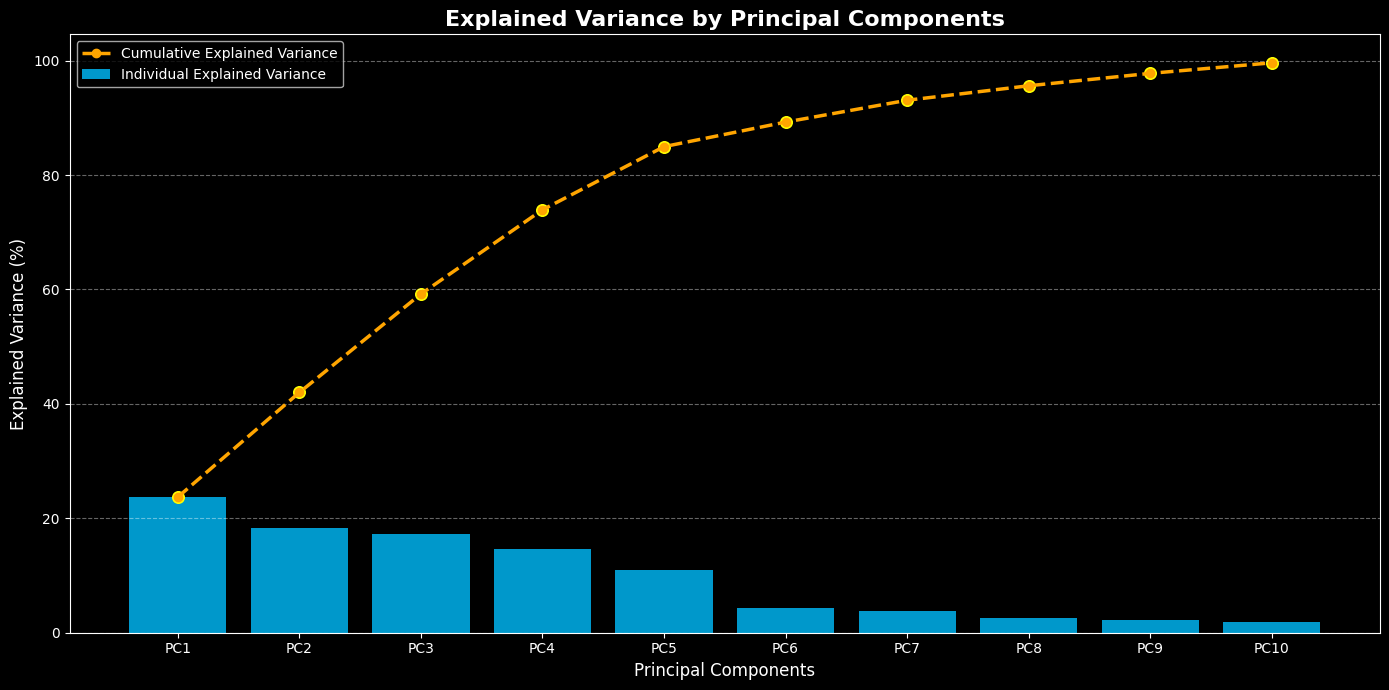

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,23.72,23.72
1,PC2,18.28,42.00
2,PC3,17.21,59.21
3,PC4,14.72,73.93
4,PC5,11.04,84.97
5,PC6,4.29,89.26
6,PC7,3.82,93.08
7,PC8,2.53,95.61
8,PC9,2.17,97.78
9,PC10,1.84,99.62


In [16]:
# 1. Create and Fit PCA Model
pca = PCA()
pca.fit(features_df)
pca_data = pca.transform(features_df)

# 2. Calculate Explained Variance
explained_variance = np.round(
    pca.explained_variance_ratio_ * 100,
    decimals=2
)

pca_labels = [
    f'PC{i}'
    for i in range(1, len(explained_variance) + 1)
]

variance_display = explained_variance[:10]
labels_display = pca_labels[:10]
cumulative_variance = np.cumsum(variance_display)

# 3. Plot Explained Variance
with plt.style.context('dark_background'):

    plt.figure(figsize=(14, 7))
    plt.bar(
        range(1, len(variance_display) + 1),
        variance_display,
        color='deepskyblue',
        alpha=0.8,
        label='Individual Explained Variance'
    )

    plt.plot(
        range(1, len(variance_display) + 1),
        cumulative_variance,
        color='orange',
        marker='o',
        linewidth=2.5,
        linestyle='--',
        label='Cumulative Explained Variance'
    )

    plt.scatter(
        range(1, len(variance_display) + 1),
        cumulative_variance,
        color='yellow',
        s=70
    )

    plt.xlabel(
        "Principal Components",
        fontsize=12
    )

    plt.ylabel(
        "Explained Variance (%)",
        fontsize=12
    )

    plt.title(
        "Explained Variance by Principal Components",
        fontsize=16,
        fontweight='bold'
    )

    plt.xticks(
        range(1, len(labels_display) + 1),
        labels_display
    )

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. Display Variance Information Table
variance_df = pd.DataFrame({
    'Principal Component': labels_display,
    'Explained Variance (%)': variance_display,
    'Cumulative Variance (%)': cumulative_variance
})

display(variance_df)


**Observation:** The PCA explained variance plot shows that the first few principal components capture a large portion of the total variance present in the customer dataset.

- The first principal component (PC1) alone explains approximately 23.72% of the total variance.
- The first two principal components together capture around 42% of the dataset variance.
- The first five principal components explain nearly 85% of the total variance, indicating that most customer behavior information can be represented using fewer dimensions.

The cumulative explained variance curve increases rapidly during the first few components and gradually stabilizes afterward. This suggests that additional principal components beyond PC5 contribute relatively less new information.

These results indicate that PCA effectively reduces the dimensional complexity of the dataset while preserving the majority of important customer behavior patterns, making the transformed data suitable for visualization, clustering, and segmentation analysis.

In [17]:
# 1. Create DataFrame using First Two PCs
pca_df = pd.DataFrame(
    data=pca_data[:, 0:2],
    columns=['PC1', 'PC2']
)

pca_df['Product_Category_Preference'] = customer_labels.values

# 2. Create Interactive PCA Scatter Plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Product_Category_Preference',
    title='Customer Segmentation using PCA',
    labels={
        'PC1': 'Principal Component 1',
        'PC2': 'Principal Component 2',
        'Product_Category_Preference': 'Product Category'
    },

    hover_data=['Product_Category_Preference'],
    width=1000,
    height=650,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 3. Customize Plot Appearance
fig.update_layout(
    template='plotly_dark',
    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': {
            'size': 22
        }
    },

    legend_title='Customer Preferences',
    font=dict(
        size=12
    )
)

fig.update_traces(
    marker=dict(
        size=8,
        opacity=0.75,
        line=dict(
            width=0.5,
            color='white'
        )
    )
)

# 4. Display Plot
fig.show(renderer="colab")


**Observations from PCA Plot:** The PCA scatter plot represents customers in a two-dimensional space using the first two principal components (PC1 and PC2), which summarize the most significant variance in customer behavior data.

The visualization shows that customer groups corresponding to different product preferences are moderately distributed across the PCA space. While some local clustering patterns are visible, there is still considerable overlap between categories such as Electronics, Fashion, Books, Home Decor, Beauty, and Sports.

This overlap indicates that many customers share similar purchasing behaviors despite having different product preferences. At the same time, certain dense regions and spread patterns suggest the presence of partially distinct customer segments.

The plot also demonstrates that PCA successfully reduces the high-dimensional dataset into a simpler visual form while preserving meaningful behavioral information. However, since the customer groups are not fully separated, this suggests that customer behavior relationships may be nonlinear in nature.

Therefore, more advanced nonlinear dimensionality reduction techniques such as t-SNE may provide clearer customer segmentation and cluster separation in later analysis.

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a nonlinear dimensionality reduction technique designed specifically for visualizing high-dimensional datasets.

Unlike PCA, which focuses on preserving global variance, t-SNE emphasizes preserving local neighborhood structures. This makes it highly effective for identifying hidden customer groups, behavioral clusters, and nonlinear relationships in customer purchasing patterns.

In this project, t-SNE is applied to the preprocessed customer dataset to visualize customer segmentation more clearly in a two-dimensional space.

### Important t-SNE Parameters

- **Perplexity:**  
  Controls the balance between local and global structure in the data. Lower values focus more on local neighborhoods, while higher values capture broader relationships.

- **n_iter:**  
  Defines the number of optimization iterations used during embedding generation.

- **Random State:**  
  Ensures reproducibility of results.

### Objective of t-SNE Analysis

The goal of applying t-SNE is to:
- reveal hidden customer clusters,
- improve customer segment visualization,
- compare results with PCA,
- and better understand nonlinear customer behavior patterns.

In [18]:
# 1. Define t-SNE Parameters
random_state = 57
n_components = 2
perplexity = 30
n_iter = 1000

print(f"Applying t-SNE with perplexity={perplexity}, n_iter={n_iter}...")

# 2. Create and Fit t-SNE Model
tsne_model = TSNE(
    n_components=n_components,
    perplexity=perplexity,
    n_iter=n_iter,
    random_state=random_state,
    init='pca',
    learning_rate='auto',
    verbose=1
)

tsne_data = tsne_model.fit_transform(features_df)
print("t-SNE completed successfully.")

# 3. Create DataFrame for Visualization
tsne_df = pd.DataFrame(
    data=tsne_data,
    columns=['TSNE1', 'TSNE2']
)
tsne_df['Product_Category_Preference'] = customer_labels.values

# 4. Create Interactive t-SNE Scatter Plot
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='Product_Category_Preference',
    title=f'Customer Segmentation using t-SNE (Perplexity = {perplexity})',
    labels={
        'TSNE1': 't-SNE Component 1',
        'TSNE2': 't-SNE Component 2',
        'Product_Category_Preference': 'Product Category'
    },

    hover_data=['Product_Category_Preference'],
    width=1000,
    height=650,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 5. Customize Plot Appearance
fig.update_layout(
    template='plotly_dark',
    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': {
            'size': 22
        }
    },

    legend_title='Customer Preferences',
    font=dict(size=12)
)

fig.update_traces(
    marker=dict(
        size=8,
        opacity=0.78,
        line=dict(
            width=0.5,
            color='white'
        )
    )
)

# 6. Display Plot
fig.show(renderer="colab")

Applying t-SNE with perplexity=30, n_iter=1000...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 650 samples in 0.002s...
[t-SNE] Computed neighbors for 650 samples in 0.027s...
[t-SNE] Computed conditional probabilities for sample 650 / 650
[t-SNE] Mean sigma: 0.915212
[t-SNE] KL divergence after 50 iterations with early exaggeration: 65.409302
[t-SNE] KL divergence after 1000 iterations: 1.283417
t-SNE completed successfully.


**Observations from t-SNE Plot:** The t-SNE visualization provides a clearer representation of customer groupings compared to the earlier PCA visualization. Unlike PCA, t-SNE preserves local neighborhood relationships more effectively, allowing hidden customer patterns and nonlinear structures to become more visible.

Several partially separated clusters can be observed across the two-dimensional embedding space, indicating the presence of distinct customer behavior groups based on purchasing patterns and product preferences.

Compared to PCA:
- customer clusters appear more compact,
- local group structures are better preserved,
- and category-based segmentation becomes more visually distinguishable.

Although some overlap between product categories still exists, the separation between customer groups is noticeably improved. This suggests that customer purchasing behavior contains nonlinear relationships that are captured more effectively by t-SNE.

The perplexity value of 30 provides a balanced visualization by preserving both local neighborhood structures and broader global relationships within the customer dataset.

Overall, the t-SNE visualization demonstrates that nonlinear dimensionality reduction techniques are more effective for discovering hidden customer segments and behavioral patterns in complex e-commerce datasets.

# 6. Conclusion and Business Implications

This project successfully applied dimensionality reduction techniques such as PCA and t-SNE to analyze and visualize customer behavior within a synthetic e-commerce dataset.

The preprocessing stage transformed customer demographic, purchasing, and product preference information into a machine-learning-ready format through encoding and feature standardization. This enabled effective dimensionality reduction and visualization of customer behavior patterns.

### Key Findings from PCA and t-SNE

- **PCA Analysis:**  
  PCA effectively reduced the dimensional complexity of the dataset while preserving most of the important variance. The first few principal components captured a large portion of customer behavioral information, allowing meaningful low-dimensional visualization.

- **t-SNE Analysis:**  
  t-SNE provided clearer visualization of hidden customer structures and nonlinear behavioral relationships. Compared to PCA, t-SNE revealed more compact local groupings and improved separation between customer segments.

- **Customer Segmentation Patterns:**  
  The visualizations revealed partially distinct customer groups based on purchasing behavior and product preferences such as Electronics, Fashion, Books, Home Decor, Beauty, and Sports.

### Potential Customer Segments Identified

Based on the clustering patterns observed in PCA and t-SNE visualizations, several customer behavior groups can be inferred:

- **High-Value Customers:**  
  Customers with high Customer_Lifetime_Value and higher Average_Order_Value who may contribute significantly to business revenue.

- **Frequent Shoppers:**  
  Customers with high Number_of_Purchases indicating strong engagement and repeat purchasing behavior.

- **Low Engagement Customers:**  
  Customers with high Days_Since_Last_Purchase or lower purchasing frequency who may require re-engagement strategies.

- **Category-Focused Customers:**  
  Customers showing strong preference toward specific product categories such as Electronics, Books, or Fashion.

**How would a business use these insights?**

The insights obtained from customer segmentation can help businesses make more informed and data-driven decisions:

- **Personalized Marketing:**  
  Businesses can target specific customer groups with customized product recommendations and promotional campaigns.

- **Customer Retention Strategies:**  
  Low-engagement customers can be identified early and targeted with discounts, loyalty programs, or re-engagement campaigns.

- **Cross-Selling Opportunities:**  
  Customers strongly associated with one product category may be encouraged to explore complementary categories.

- **Improved Product Planning:**  
  Understanding customer purchasing behavior helps businesses optimize inventory management and product offerings.

This project demonstrates how dimensionality reduction techniques can simplify complex customer datasets while preserving meaningful behavioral patterns. Both PCA and t-SNE proved valuable for customer segmentation and exploratory data analysis.



# Continuation: Applying Customer Segmentation to Real-World E-commerce Data
**Introduction: From Synthetic to Real-World Challenges**

After successfully analyzing customer behavior using a synthetic dataset, the next step is to apply the same dimensionality reduction and visualization techniques to a real-world e-commerce dataset.

Unlike synthetic data, real-world transactional datasets contain:
- missing values,
- noisy records,
- duplicate transactions,
- inconsistent customer behavior,
- and more complex purchasing patterns.

This section focuses on analyzing the **Online Retail Dataset**, a widely used real-world e-commerce dataset containing transactional purchase records from a UK-based online retail company.

By working with real transactional data, this analysis aims to:
- perform practical data cleaning and preprocessing,
- derive meaningful customer behavior features,
- identify real customer segments,
- apply PCA and t-SNE for visualization,
- and generate business-oriented customer insights.

### Objectives of Real-World Analysis

- Understand customer purchasing behavior using transactional records.
- Build meaningful customer-level features from raw sales data.
- Apply dimensionality reduction techniques on real customer behavior data.
- Discover hidden customer groups and purchasing patterns.
- Analyze potential business implications from customer segmentation.

This section demonstrates how machine learning and visualization techniques can support data-driven decision-making in real-world e-commerce environments.

# 1. Real Data Acquisition and Initial Exploration: Online Retail Dataset

# 1. Real Data Acquisition and Initial Exploration: Customer Transaction Dataset

In this section, we transition from synthetic customer behavior data to a real-world customer transaction dataset containing actual e-commerce purchase records.

The dataset includes transactional information related to customer purchases, product details, pricing, and purchasing activity. Unlike the synthetic dataset used earlier, this real-world dataset reflects practical customer behavior patterns and business operations.

### Dataset Overview

The dataset contains important transactional features such as:

- Customer identifiers
- Product descriptions
- Purchase quantities
- Unit prices
- Invoice details
- Transaction dates
- Country information

Each row represents an individual transaction made by a customer.

### Importance of Real-World Customer Data

Real transactional datasets provide more realistic insights into:
- customer purchasing behavior,
- buying frequency,
- spending patterns,
- customer engagement,
- and product demand trends.

Analyzing real-world customer data helps businesses better understand customer segments and make data-driven decisions.

### Challenges in Real-World Data

Unlike synthetic datasets, real-world e-commerce data often contains:
- missing customer records,
- cancelled transactions,
- duplicate entries,
- invalid quantities or prices,
- noisy purchasing behavior,
- and inconsistent customer activity.

Therefore, careful preprocessing and feature engineering are necessary before applying dimensionality reduction techniques such as PCA and t-SNE.

### Objectives of This Section

The main objectives of this real-world analysis are:

- Clean and preprocess transactional customer data.
- Create meaningful customer-level behavioral features.
- Apply dimensionality reduction techniques for visualization.
- Discover hidden customer segments and purchasing patterns.
- Generate business insights from customer behavior analysis.

This section demonstrates how customer segmentation techniques can be applied in practical e-commerce analytics environments using real transactional data.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# 2. Load Online Retail Dataset

print("Initializing dataset loading process...")
dataset_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00352/"
    "Online%20Retail.xlsx"
)

try:

    df_raw = pd.read_excel(dataset_url)
    print("Dataset loaded successfully from UCI repository!")

except Exception as error:
    print(f"\nError while accessing online dataset:\n{error}")
    print("\nAttempting local file loading...")
    try:
        df_raw = pd.read_excel("Online Retail.xlsx")

        print("Dataset loaded successfully from local storage!")

    except FileNotFoundError:
        print("\nLocal dataset file was not found.")
        print("\nDownload the dataset manually from:")
        print("https://archive.ics.uci.edu/ml/datasets/Online+Retail")
        print("\nPlace 'Online Retail.xlsx' in the current notebook directory.")

        # Empty DataFrame fallback
        df_raw = pd.DataFrame()

# 3. Initial Dataset Exploration

if not df_raw.empty:
    print("Dataset Dimensions")
    print(f"Rows: {df_raw.shape[0]}")
    print(f"Columns: {df_raw.shape[1]}")
    print("Preview of Dataset")
    display(df_raw.head())
    print("Dataset Information")
    df_raw.info()
    print("Missing Values Analysis")
    display(df_raw.isnull().sum())
    print("Statistical Summary")
    display(df_raw.describe())
else:
    print("\nDataset could not be loaded.")
    print("Please resolve dataset loading issues before proceeding.")

Initializing dataset loading process...
Dataset loaded successfully from UCI repository!
Dataset Dimensions
Rows: 541909
Columns: 8
Preview of Dataset


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
Missing Values Analysis


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Statistical Summary


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


The Online Retail dataset contains transactional records of a UK-based e-commerce company. Each row represents an individual product purchase made by a customer.

The dataset consists of approximately 541,909 transaction records and 8 features, including invoice details, product descriptions, quantities, transaction dates, pricing information, customer identifiers, and country information.

Initial exploration reveals that:
- The dataset contains missing values, particularly in the CustomerID and Description columns.
- Most transactions originate from the United Kingdom.
- CustomerID has a significant number of missing entries, which will require preprocessing before customer-level analysis.
- Numerical features such as Quantity and UnitPrice show large variation, indicating diverse purchasing behavior among customers.

These observations highlight the need for data cleaning and preprocessing before applying dimensionality reduction and customer segmentation techniques.

# 2. Real Data Preprocessing and Feature Engineering (RFM Metrics)

To perform meaningful customer segmentation on the real-world e-commerce dataset, customer-level behavioral features must first be engineered from the raw transactional records.

In this project, we use the widely adopted **RFM (Recency, Frequency, Monetary)** framework for customer analysis and segmentation.

### RFM Metrics

- **Recency (R):**  
  Measures how recently a customer made a purchase. Customers with more recent transactions are generally considered more engaged.

- **Frequency (F):**  
  Represents how often a customer makes purchases, calculated using the total number of unique invoices or transactions.

- **Monetary Value (M):**  
  Measures the total amount spent by a customer across all purchases.

These metrics are highly effective for identifying:
- loyal customers,
- high-value customers,
- inactive customers,
- and different purchasing behavior patterns.

Before calculating RFM features, the transactional dataset requires cleaning and preprocessing.

#### 1. Data Cleaning

The following preprocessing operations will be performed:

- Remove records with missing `CustomerID` values.
- Remove cancelled or returned transactions where `Quantity <= 0`.
- Remove invalid transactions where `UnitPrice <= 0`.
- Handle duplicate or inconsistent records if necessary.

#### 2. Create Transactional Spending Feature

A new feature called **TotalPrice** will be created:

TotalPrice = Quantity × UnitPrice

In [20]:
# 1. Create Working Copy of Dataset
df = df_raw.copy()

# 2. Data Cleaning
print("Starting data preprocessing...")

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Remove cancelled/returned transactions
df = df[df['Quantity'] > 0]

# Remove invalid product prices
df = df[df['UnitPrice'] > 0]

# Remove duplicate records
df = df.drop_duplicates()
print("Cleaned Dataset Information")
print(f"Dataset Shape After Cleaning: {df.shape}")
print(f"\nUnique Customers: {df['CustomerID'].nunique()}")
print(f"Unique Products: {df['StockCode'].nunique()}")
print(f"Countries Present: {df['Country'].nunique()}")

# 3. Create Total Spending Feature
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("\nTotalPrice feature created successfully.")

# 4. Define Analysis Reference Date
latest_transaction_date = df['InvoiceDate'].max()

# Add one day for recency calculation
analysis_date = latest_transaction_date + pd.Timedelta(days=1)
print(f"\nReference Date for Recency Analysis: {analysis_date}")

# 5. Generate RFM Features
rfm_df = (
    df.groupby('CustomerID')
      .agg({
          'InvoiceDate': lambda x: (analysis_date - x.max()).days,
          'InvoiceNo': 'nunique',
          'TotalPrice': 'sum'
      })
      .reset_index()
)
rfm_df.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]
print("RFM Feature Dataset")
display(rfm_df.head())
print("\nRFM Feature Statistics:")
display(rfm_df.describe())

# 6. Add Country Information
customer_country = (
    df[['CustomerID', 'Country']]
    .drop_duplicates(subset=['CustomerID'])
    .set_index('CustomerID')
)
rfm_df['Country'] = rfm_df['CustomerID'].map(
    customer_country['Country']
)

# 7. Prepare Features for Scaling
rfm_features = rfm_df.drop(
    columns=['CustomerID', 'Country']
)

# 8. Standardize RFM Features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled values into DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features.columns
)
print("Scaled RFM Features")
display(rfm_scaled_df.head())

Starting data preprocessing...
Cleaned Dataset Information
Dataset Shape After Cleaning: (392692, 8)

Unique Customers: 4338
Unique Products: 3665
Countries Present: 37

TotalPrice feature created successfully.

Reference Date for Recency Analysis: 2011-12-10 12:50:00
RFM Feature Dataset


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40



RFM Feature Statistics:


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


Scaled RFM Features


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


The preprocessing stage successfully cleaned and transformed the real-world transactional dataset into customer-level RFM features suitable for customer segmentation analysis.

After cleaning:
- The dataset contains approximately 392,692 valid transaction records.
- A total of 4,338 unique customers were identified.
- Transactions were recorded across 37 different countries.

The RFM feature engineering process generated three important customer behavior metrics:
- **Recency:** Number of days since the customer's last purchase.
- **Frequency:** Number of unique purchases made by the customer.
- **Monetary:** Total spending amount of the customer.

The statistical summary indicates significant variation in customer purchasing behavior:
- Some customers purchase very frequently,
- while others make only occasional purchases.
- Monetary values also vary widely, indicating the presence of both low-value and high-value customers.

Finally, the RFM features were standardized using `StandardScaler()`, ensuring that all features operate on a similar scale before applying dimensionality reduction techniques such as PCA and t-SNE.

# 3. Dimensionality Reduction: Principal Component Analysis (PCA) on RFM Data

After preprocessing and standardizing the RFM metrics, Principal Component Analysis (PCA) is applied to reduce the dimensional complexity of customer behavior data while preserving the most important variance.

In this analysis, PCA helps summarize customer purchasing behavior patterns based on:
- Recency,
- Frequency,
- and Monetary spending values.

By transforming the standardized RFM features into principal components, PCA enables:
- easier visualization of customer behavior,
- identification of dominant purchasing patterns,
- reduction of feature redundancy,
- and preparation for customer segmentation analysis.

The first few principal components capture the majority of behavioral variation among customers, allowing high-dimensional customer data to be represented effectively in a lower-dimensional space.

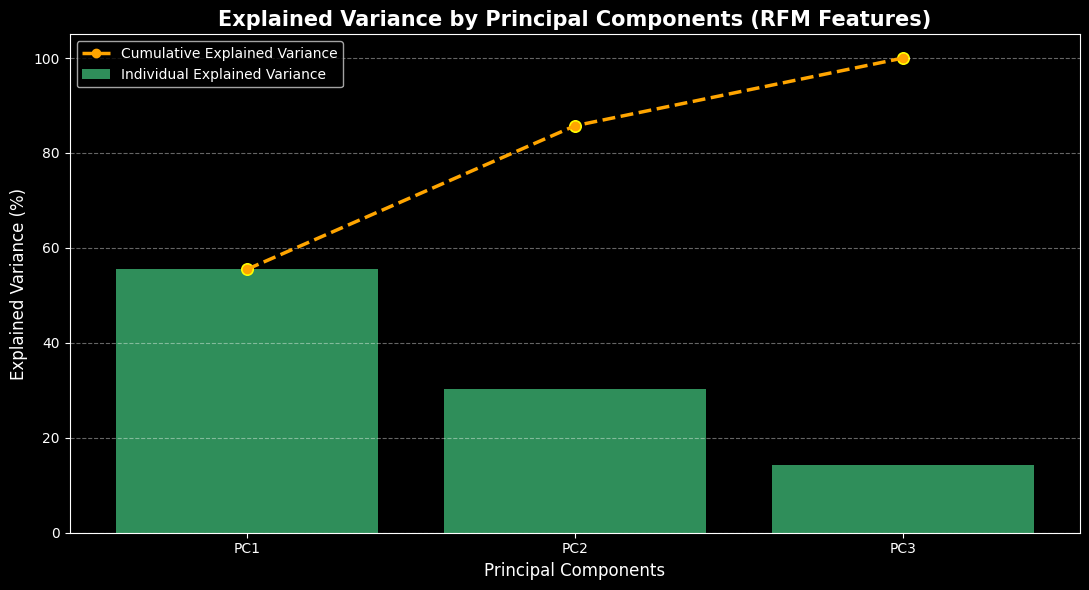

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,55.47,55.47
1,PC2,30.25,85.72
2,PC3,14.27,99.99


In [21]:
# 1. Create and Fit PCA Model on RFM Features
pca_rfm = PCA()

# Fit PCA on standardized RFM dataset
pca_rfm.fit(rfm_scaled_df)

# Transform RFM features into PCA space
pca_rfm_data = pca_rfm.transform(rfm_scaled_df)

# 2. Calculate Explained Variance
explained_variance_rfm = np.round(
    pca_rfm.explained_variance_ratio_ * 100,
    decimals=2
)

pca_labels_rfm = [
    f'PC{i}'
    for i in range(1, len(explained_variance_rfm) + 1)
]

# Since RFM contains only 3 features
variance_display_rfm = explained_variance_rfm[:3]
labels_display_rfm = pca_labels_rfm[:3]

# Calculate cumulative variance
cumulative_variance_rfm = np.cumsum(
    variance_display_rfm
)

# 3. Plot Explained Variance
with plt.style.context('dark_background'):
    plt.figure(figsize=(11, 6))

    # Bar plot
    plt.bar(
        range(1, len(variance_display_rfm) + 1),
        variance_display_rfm,
        color='mediumseagreen',
        alpha=0.8,
        label='Individual Explained Variance'
    )

    # Cumulative variance line
    plt.plot(
        range(1, len(variance_display_rfm) + 1),
        cumulative_variance_rfm,
        color='orange',
        marker='o',
        linestyle='--',
        linewidth=2.5,
        label='Cumulative Explained Variance'
    )

    # Scatter points
    plt.scatter(
        range(1, len(variance_display_rfm) + 1),
        cumulative_variance_rfm,
        color='yellow',
        s=70
    )

    # Axis labels
    plt.xlabel(
        "Principal Components",
        fontsize=12
    )

    plt.ylabel(
        "Explained Variance (%)",
        fontsize=12
    )

    # Title
    plt.title(
        "Explained Variance by Principal Components (RFM Features)",
        fontsize=15,
        fontweight='bold'
    )

    # Tick labels
    plt.xticks(
        range(1, len(labels_display_rfm) + 1),
        labels_display_rfm
    )

    # Grid
    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    # Legend
    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. Display Variance Information

variance_rfm_df = pd.DataFrame({
    'Principal Component': labels_display_rfm,
    'Explained Variance (%)': variance_display_rfm,
    'Cumulative Variance (%)': cumulative_variance_rfm
})

display(variance_rfm_df)

**Observation:** The PCA analysis on the RFM features shows that the first principal component (PC1) explains approximately 55.47% of the total variance in customer purchasing behavior.

Together, the first two principal components (PC1 and PC2) capture nearly 85.72% of the total variance, indicating that most customer behavior information can be represented effectively in a two-dimensional space.

The third principal component contributes a smaller portion of variance, suggesting that the majority of customer purchasing patterns are already captured by the first two components.

These results demonstrate that PCA successfully reduces the dimensional complexity of the RFM dataset while preserving the most important behavioral information required for customer segmentation and visualization.

Now, let's visualize the customers in the 2D PCA space, coloring them by Country to see if geographic location plays a role in customer behavior patterns. We'll focus on the top 10 countries by customer count to keep the legend manageable, and group others as 'Other'.

In [22]:
# 1. Prepare PCA Data for Visualization
pca_rfm_df = pd.DataFrame(
    data=pca_rfm_data[:, :2],
    columns=['PC1', 'PC2']
)

pca_rfm_df['CustomerID'] = rfm_df['CustomerID']

# 2. Merge Country Information
country_info = rfm_df[['CustomerID', 'Country']]

pca_rfm_df = pd.merge(
    pca_rfm_df,
    country_info,
    on='CustomerID',
    how='left'
)

# 3. Group Smaller Countries
top_countries = (
    pca_rfm_df['Country']
    .value_counts()
    .nlargest(10)
    .index
)

pca_rfm_df['Country_Grouped'] = (
    pca_rfm_df['Country']
    .apply(
        lambda country:
        country if country in top_countries else 'Other'
    )
)

# 4. Create PCA Scatter Plot
fig = px.scatter(
    pca_rfm_df,
    x='PC1',
    y='PC2',
    color='Country_Grouped',
    title='Customer Segmentation using PCA (Grouped by Country)',
    labels={
        'PC1': 'Principal Component 1',
        'PC2': 'Principal Component 2',
        'Country_Grouped': 'Country'
    },

    hover_data=[
        'Country',
        'PC1',
        'PC2'
    ],

    width=1000,
    height=650,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

# 5. Customize Plot
fig.update_layout(
    template='plotly_dark',
    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': {
            'size': 21
        }
    },
    legend_title='Customer Country',
    font=dict(size=12)
)

# Improve marker appearance
fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.75,
        line=dict(
            width=0.4,
            color='white'
        )
    )
)

# 6. Display Plot
fig.show(renderer="colab")

The next natural step is to apply t-SNE and then UMAP to the real RFM data.

This will allow us to compare how these non-linear methods perform in revealing customer segments compared to PCA, especially with real-world complexities.

Let's continue with t-SNE:

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE) on RFM Data

As we saw with the synthetic data, t-SNE excels at uncovering non-linear relationships and local clusters within the data. With our real RFM features, t-SNE should provide a more nuanced view of customer segments compared to the linear PCA.

We'll use the same perplexity and n_iter parameters as a starting point, but remember that experimenting with these values is key to finding the most insightful visualization for your specific dataset.

In [23]:
# 1. Configure t-SNE Parameters
random_seed = 42
tsne_components = 2
perplexity_value = 30
iterations = 1000
print(
    f"Running t-SNE on RFM data "
    f"(Perplexity={perplexity_value}, Iterations={iterations})..."
)

# 2. Create and Fit t-SNE Model
tsne_model = TSNE(
    n_components=tsne_components,
    perplexity=perplexity_value,
    n_iter=iterations,
    random_state=random_seed,
    verbose=1
)
tsne_rfm_data = tsne_model.fit_transform(
    rfm_scaled_df
)

print("\nt-SNE dimensionality reduction completed successfully.")

# 3. Create t-SNE DataFrame
tsne_rfm_df = pd.DataFrame(
    tsne_rfm_data,
    columns=['TSNE1', 'TSNE2']
)
tsne_rfm_df['CustomerID'] = rfm_df['CustomerID']
tsne_rfm_df['Country'] = rfm_df['Country']

# 4. Group Less Frequent Countries
top_countries = (
    tsne_rfm_df['Country']
    .value_counts()
    .nlargest(10)
    .index
)
tsne_rfm_df['Country_Grouped'] = (
    tsne_rfm_df['Country']
    .apply(
        lambda country:
        country if country in top_countries else 'Other'
    )
)

# 5. Visualize t-SNE Results
fig = px.scatter(
    tsne_rfm_df,
    x='TSNE1',
    y='TSNE2',
    color='Country_Grouped',
    title=f'Customer Segmentation using t-SNE (Perplexity = {perplexity_value})',
    labels={
        'TSNE1': 't-SNE Component 1',
        'TSNE2': 't-SNE Component 2',
        'Country_Grouped': 'Country'
    },
    hover_data=[
        'CustomerID',
        'Country'
    ],
    width=1000,
    height=700,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

# 6. Customize Plot Appearance
fig.update_layout(
    template='plotly_dark',
    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': {
            'size': 22
        }
    },
    legend_title='Customer Country',
    font=dict(size=12)
)
fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.75,
        line=dict(
            width=0.4,
            color='white'
        )
    )
)

# 7. Display Plot
fig.show(renderer="colab")

Running t-SNE on RFM data (Perplexity=30, Iterations=1000)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4338 samples in 0.003s...
[t-SNE] Computed neighbors for 4338 samples in 0.098s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4338
[t-SNE] Computed conditional probabilities for sample 2000 / 4338
[t-SNE] Computed conditional probabilities for sample 3000 / 4338
[t-SNE] Computed conditional probabilities for sample 4000 / 4338
[t-SNE] Computed conditional probabilities for sample 4338 / 4338
[t-SNE] Mean sigma: 0.035120
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.506168
[t-SNE] KL divergence after 1000 iterations: 0.484017

t-SNE dimensionality reduction completed successfully.


**Observations from t-SNE Plot on RFM Data:**
The t-SNE visualization reveals several distinct customer clusters based on the RFM features, indicating the presence of different purchasing behavior patterns within the e-commerce dataset.

Compared to PCA, t-SNE provides a clearer separation of customer groups by preserving nonlinear relationships and local neighborhood structures. Customers with similar purchasing behavior appear closer together, forming compact clusters across the visualization space.

The plot suggests that:
- some customers exhibit highly similar spending and purchasing frequency patterns,
- while others form isolated groups representing unique purchasing behavior.

Although overlap between countries still exists, the clustering structure demonstrates that t-SNE is highly effective for uncovering hidden customer segments in real-world transactional data.

Overall, the visualization confirms that customer purchasing behavior contains complex nonlinear patterns that are captured more effectively by t-SNE than linear dimensionality reduction techniques such as PCA.

# 5. Comprehensive Interpretation and Business Implications (Real Data)
The application of PCA and t-SNE on the real-world RFM dataset provided meaningful insights into customer purchasing behavior and customer segmentation patterns.

Both dimensionality reduction techniques helped simplify complex customer behavior data while preserving important purchasing relationships among customers.

### Key Insights from PCA and t-SNE

#### PCA Interpretation

The PCA visualization showed that a large portion of customer behavior variance could be represented using the first few principal components. This indicates that customer purchasing patterns are strongly influenced by the RFM metrics:
- Recency,
- Frequency,
- and Monetary spending.

PCA provided a clear overview of the overall customer distribution and behavioral variation within the dataset.

#### t-SNE Interpretation

Compared to PCA, t-SNE produced more distinct and compact customer clusters by capturing nonlinear relationships within the RFM features.

The t-SNE visualization revealed:
- localized customer groups,
- hidden purchasing behavior patterns,
- and stronger separation between customer segments.

This demonstrates that customer purchasing behavior in real-world e-commerce environments is often nonlinear and complex.

---

## Business Implications

The discovered customer patterns can support several important business strategies.

### High-Value Customers

Customers with:
- high spending,
- frequent purchases,
- and recent activity

can be identified as loyal or premium customers.

Businesses can:
- offer loyalty rewards,
- provide personalized recommendations,
- and prioritize premium customer support.

### Low Engagement or Churn-Risk Customers

Customers with:
- high recency values,
- low purchase frequency,
- or reduced spending behavior

may represent churn-risk customers.

Businesses can target these customers using:
- discount campaigns,
- re-engagement emails,
- and personalized promotional offers.

### Frequent Buyers

Customers with high purchase frequency may respond well to:
- membership programs,
- subscription models,
- and early product access campaigns.

### Geographic Customer Insights

Country-based visualization also highlights customer distribution across different regions. This can help businesses:
- identify region-specific customer behavior,
- optimize international marketing strategies,
- and improve localized product recommendations.

---

## Comparison of PCA and t-SNE

| Technique | Strength |
|---|---|
| PCA | Efficiently captures overall variance and provides simpler linear visualization |
| t-SNE | Better reveals hidden clusters and nonlinear customer behavior patterns |

In this project, t-SNE produced more visually distinguishable customer groups, making it more effective for exploratory customer segmentation analysis.

---

## Final Conclusion

This real-world analysis demonstrates the importance of preprocessing, feature engineering, and dimensionality reduction techniques in understanding customer purchasing behavior.

By combining RFM analysis with PCA and t-SNE visualization techniques, meaningful customer segments and behavioral patterns can be identified from complex transactional datasets.

Overall, the project highlights how machine learning and data visualization techniques can support strategic decision-making in modern e-commerce businesses.

This real-world exercise demonstrates that while data preprocessing and feature engineering require more effort, the insights gained can be directly translated into tangible business strategies. Visualizing the data is often the crucial first step in understanding complex patterns and driving informed decision-making.